# 🎬 Sentiment Analysis on IMDB Movie Reviews — NLP Task 1

> **Dataset:** Raw IMDB aclImdb folder (50,000 reviews from .txt files)  
> **Tools:** Python | Pandas | NLTK | Scikit-learn

## 📌 Learning Roadmap
| Stage | Description |
|-------|-------------|
| 0 | 📂 Load Raw Dataset from Folder Structure → Save as CSV |
| 1 | ⚙️ Setup & Imports |
| 2 | 📊 Dataset Exploration (EDA) |
| 3 | 🧹 Text Preprocessing Pipeline |
| 4 | 🔢 Feature Extraction (BoW + TF-IDF) |
| 5 | 🤖 Model Training (Logistic Regression + Naive Bayes) |
| 6 | 📈 Evaluation & Metrics |
| 7 | 🎨 Visualizations |
| 8 | 🚀 Production Pipeline & Live Inference |

---
## 📂 Stage 0: Load Raw IMDB Dataset from Folder Structure

**Your dataset folder looks like this:**
```
aclImdb/
├── train/
│   ├── pos/   ← 12,500 positive review .txt files
│   ├── neg/   ← 12,500 negative review .txt files
│   └── unsup/ ← 50,000 unlabeled reviews (we SKIP these)
└── test/
    ├── pos/   ← 12,500 positive review .txt files
    └── neg/   ← 12,500 negative review .txt files
```
**Total labeled reviews = 50,000** (25k train + 25k test)

> ✅ This stage reads all `.txt` files, combines them into one DataFrame, and saves a clean `imdb_reviews.csv` so you never have to do this again.

In [32]:
import os
import pandas as pd

# ══════════════════════════════════════════════════════
#  ⚠️  SET THIS TO YOUR EXTRACTED FOLDER PATH
# ══════════════════════════════════════════════════════
# Examples:
#   Windows : DATASET_ROOT = r"C:\Users\YourName\Downloads\aclImdb"
#   Mac/Linux: DATASET_ROOT = "/home/yourname/Downloads/aclImdb"
#   Same folder as notebook: DATASET_ROOT = "aclImdb"

DATASET_ROOT = "aclImdb"   # ← CHANGE THIS to your actual path
OUTPUT_CSV   = "imdb_reviews.csv"   # We'll save the combined dataset here

# Quick check
if os.path.exists(DATASET_ROOT):
    print(f"✅ Found dataset folder: {DATASET_ROOT}")
    for split in ["train", "test"]:
        for label in ["pos", "neg"]:
            path = os.path.join(DATASET_ROOT, split, label)
            count = len(os.listdir(path)) if os.path.exists(path) else 0
            print(f"   {split}/{label}: {count:,} files")
else:
    print(f"❌ Folder not found: '{DATASET_ROOT}'")
    print("   → Update DATASET_ROOT above to point to your aclImdb folder")

✅ Found dataset folder: aclImdb
   train/pos: 12,500 files
   train/neg: 12,500 files
   test/pos: 12,500 files
   test/neg: 12,500 files


In [33]:
def load_imdb_from_folders(root_path: str) -> pd.DataFrame:
    """
    Reads all .txt review files from the aclImdb folder structure.
    Combines train/pos, train/neg, test/pos, test/neg into one DataFrame.
    Skips 'unsup' folder (unlabeled data — not useful for classification).
    
    Returns a DataFrame with columns: [text, sentiment, split]
    """
    records = []
    
    for split in ["train", "test"]:
        for label in ["pos", "neg"]:
            folder = os.path.join(root_path, split, label)
            
            if not os.path.exists(folder):
                print(f"  ⚠ Folder not found, skipping: {folder}")
                continue
            
            txt_files = [f for f in os.listdir(folder) if f.endswith(".txt")]
            print(f"  → Reading {len(txt_files):,} files from {split}/{label}...")
            
            for filename in txt_files:
                filepath = os.path.join(folder, filename)
                try:
                    with open(filepath, "r", encoding="utf-8") as f:
                        text = f.read().strip()
                except UnicodeDecodeError:
                    # Fallback encoding for some edge-case files
                    with open(filepath, "r", encoding="latin-1") as f:
                        text = f.read().strip()
                
                # Extract rating from filename: e.g., 1234_8.txt → rating = 8
                # IMDB filenames follow the pattern: id_rating.txt
                try:
                    rating = int(filename.replace(".txt", "").split("_")[1])
                except:
                    rating = None
                
                records.append({
                    "text"      : text,
                    "sentiment" : label,      # "pos" or "neg"
                    "split"     : split,      # "train" or "test"
                    "rating"    : rating,     # original IMDB star rating
                    "filename"  : filename,
                })
    
    df = pd.DataFrame(records)
    
    # Normalize: pos → positive, neg → negative
    df["sentiment"] = df["sentiment"].map({"pos": "positive", "neg": "negative"})
    
    return df.reset_index(drop=True)


# ── Load all files ────────────────────────────────────────────────────────────
print("📂 Loading IMDB dataset from folder structure...\n")
df_raw = load_imdb_from_folders(DATASET_ROOT)

print(f"\n✅ Total reviews loaded: {len(df_raw):,}")
print(df_raw.head(3))

📂 Loading IMDB dataset from folder structure...

  → Reading 12,500 files from train/pos...
  → Reading 12,500 files from train/neg...
  → Reading 12,500 files from test/pos...
  → Reading 12,500 files from test/neg...

✅ Total reviews loaded: 50,000
                                                text sentiment  split  rating  \
0  MEN OF HONOR features Cuba Gooding Jr., in wha...  positive  train       8   
1  Yet another example of what British cinema can...  positive  train       7   
2  I really like this film... when I started to w...  positive  train      10   

      filename  
0   6403_8.txt  
1  10490_7.txt  
2  3587_10.txt  


In [34]:
# ── Save to CSV (do this once — saves time next run) ─────────────────────────
df_raw.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved combined dataset to: {OUTPUT_CSV}")
print(f"   File size: {os.path.getsize(OUTPUT_CSV) / 1024 / 1024:.1f} MB")
print()
print("💡 TIP: Next time you run this notebook, you can skip Stage 0 and")
print(f"        just load the CSV directly with: df = pd.read_csv('{OUTPUT_CSV}')")

✅ Saved combined dataset to: imdb_reviews.csv
   File size: 64.1 MB

💡 TIP: Next time you run this notebook, you can skip Stage 0 and
        just load the CSV directly with: df = pd.read_csv('imdb_reviews.csv')


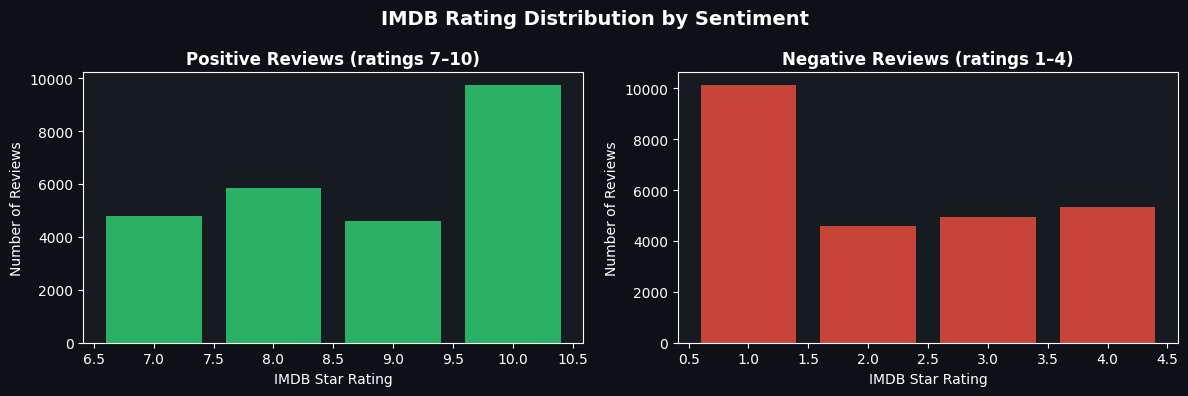

✅ Real IMDB ratings extracted from filenames — interesting insight!


In [35]:
# ── BONUS: Rating Distribution (extra insight from filename metadata) ─────────
# IMDB labels: pos reviews have ratings 7-10, neg reviews have ratings 1-4
# Ratings 5-6 were excluded by IMDB (too neutral)

if df_raw["rating"].notna().any():
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#0d1117")
    fig.suptitle("IMDB Rating Distribution by Sentiment", color="white", fontsize=14, fontweight="bold")

    for ax, sentiment, color, title in [
        (axes[0], "positive", "#2ecc71", "Positive Reviews (ratings 7–10)"),
        (axes[1], "negative", "#e74c3c", "Negative Reviews (ratings 1–4)"),
    ]:
        ax.set_facecolor("#161b22")
        ratings = df_raw[df_raw["sentiment"] == sentiment]["rating"].dropna()
        counts  = ratings.value_counts().sort_index()
        ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor="none")
        ax.set_xlabel("IMDB Star Rating", color="white")
        ax.set_ylabel("Number of Reviews", color="white")
        ax.set_title(title, color="white", fontweight="bold")
        ax.tick_params(colors="white")

    plt.tight_layout()
    plt.savefig("outputs/00_rating_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print("✅ Real IMDB ratings extracted from filenames — interesting insight!")

---
## ⚙️ Stage 1: Imports & Configuration

In [36]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("⚠ WordCloud not installed. Run: pip install wordcloud")

warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.2
MAX_FEATURES = 10_000
NGRAM_RANGE  = (1, 2)
OUTPUT_DIR   = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for resource in ["punkt", "stopwords", "wordnet", "averaged_perceptron_tagger", "punkt_tab"]:
    nltk.download(resource, quiet=True)

print("✅ All imports ready!")

✅ All imports ready!


---
## 📊 Stage 2: Dataset Exploration (EDA)

> **Already loaded from Stage 0.** This stage explores patterns in your 50k reviews.

In [37]:
# ── Use the DataFrame loaded in Stage 0 ──────────────────────────────────────
# If you're restarting the kernel and skipping Stage 0, uncomment this:
# df_raw = pd.read_csv("imdb_reviews.csv")

# Work with the full labeled data (combine train + test splits into one pool)
df = df_raw[["text", "sentiment"]].copy()

print("📊 DATASET OVERVIEW")
print(f"   Total reviews    : {len(df):,}")
print(f"   Positive reviews : {(df['sentiment']=='positive').sum():,} "
      f"({(df['sentiment']=='positive').mean()*100:.1f}%)")
print(f"   Negative reviews : {(df['sentiment']=='negative').sum():,} "
      f"({(df['sentiment']=='negative').mean()*100:.1f}%)")

# Word count per review
df["review_length"] = df["text"].apply(lambda x: len(str(x).split()))
print("\n📝 REVIEW LENGTH STATS (words)")
print(df["review_length"].describe().round(1))

df.head(3)

📊 DATASET OVERVIEW
   Total reviews    : 50,000
   Positive reviews : 25,000 (50.0%)
   Negative reviews : 25,000 (50.0%)

📝 REVIEW LENGTH STATS (words)
count    50000.0
mean       231.2
std        171.3
min          4.0
25%        126.0
50%        173.0
75%        280.0
max       2470.0
Name: review_length, dtype: float64


,text,sentiment,review_length
0,"MEN OF HONOR features Cuba Gooding Jr., in wha...",positive,182
1,Yet another example of what British cinema can...,positive,129
2,I really like this film... when I started to w...,positive,111


In [38]:
# ── Optional: Inspect the original train/test split from IMDB ────────────────
# IMDB originally provided a 50/50 train-test split.
# We combine them and re-split for our own experiments (more control).

print("Original IMDB splits:")
print(df_raw.groupby(["split", "sentiment"]).size().to_string())
print()
print("💡 We combine all 50k reviews and create our own 80/20 train-test split.")
print("   This gives models more training data and ensures a consistent split.")

Original IMDB splits:
split  sentiment
test   negative     12500
       positive     12500
train  negative     12500
       positive     12500

💡 We combine all 50k reviews and create our own 80/20 train-test split.
   This gives models more training data and ensures a consistent split.


---
## 🧹 Stage 3: Text Preprocessing Pipeline

**Why?** Raw IMDB reviews contain lots of noise:
- `<br />` HTML tags (very common in IMDB data)
- Contractions: `don't`, `wasn't`, `I've`
- Punctuation, numbers, special characters
- Common filler words: `the`, `is`, `at`

### Pipeline Steps:
`Lowercase → Remove HTML → Expand contractions → Remove special chars → Tokenize → Remove stopwords (keep negations!) → Lemmatize`

In [39]:
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()
STOP_WORDS = set(stopwords.words("english"))

# ⚠️ Keep negation words — critical for sentiment!
# "not good" and "good" mean opposite things!
NEGATION_WORDS = {"no", "not", "nor", "never", "neither", "nobody",
                  "nothing", "nowhere", "hardly", "barely", "scarcely", "without"}
STOP_WORDS -= NEGATION_WORDS

CONTRACTIONS = {
    "n't": " not", "'re": " are", "'s": " is",  "'d": " would",
    "'ll": " will", "'ve": " have", "'m": " am",
    "can't": "can not", "won't": "will not", "don't": "do not",
    "didn't": "did not", "doesn't": "does not", "isn't": "is not",
    "wasn't": "was not", "weren't": "were not", "wouldn't": "would not",
    "couldn't": "could not", "shouldn't": "should not", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not", "i've": "i have",
    "i'm": "i am", "i'll": "i will", "i'd": "i would",
}

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>|<.*?>", " ", text)     # Remove HTML (esp. <br /> common in IMDB)
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    text = re.sub(r"[^a-z\s]", " ", text)             # Keep only letters
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_text(text: str, use_lemmatization: bool = True) -> str:
    text   = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(t, pos="v") for t in tokens]
        tokens = [lemmatizer.lemmatize(t, pos="n") for t in tokens]
    else:
        tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

# ── Show before/after example ─────────────────────────────────────────────────
sample = df[df["sentiment"] == "negative"].iloc[5]
print("📋 PREPROCESSING EXAMPLE:")
print(f"  BEFORE: {sample['text'][:200]}")
print()
print(f"  AFTER : {preprocess_text(sample['text'])[:200]}")

📋 PREPROCESSING EXAMPLE:
  BEFORE: Really, everybody in this movie looks like they want to be someplace else! No wonder, the casting is done not with the left hand, but rather not at all. I haven't seen anything worse than Natascha McE

  AFTER : really everybody movie look like want someplace else wonder cast do not leave hand rather not not see anything worse natascha mcelhone impersonate sort agent carry gun not use spoil city brat look rol


In [40]:
# ── Apply to full dataset ─────────────────────────────────────────────────────
# ⏱️  50,000 reviews: expect 4–8 minutes depending on your machine
print("→ Preprocessing 50,000 reviews... (this takes a few minutes)")
print("  Progress will show below:")

start = time.time()

# tqdm gives a live progress bar — install with: pip install tqdm
try:
    from tqdm import tqdm
    tqdm.pandas()
    df["processed_text"] = df["text"].progress_apply(preprocess_text)
except ImportError:
    # Fallback: batch progress counter
    texts, total = [], len(df)
    for i, text in enumerate(df["text"]):
        texts.append(preprocess_text(text))
        if (i + 1) % 5000 == 0:
            print(f"  {i+1:,}/{total:,} done ({(i+1)/total*100:.0f}%)...")
    df["processed_text"] = texts

elapsed = time.time() - start
print(f"\n✅ Preprocessing complete in {elapsed:.0f}s ({elapsed/60:.1f} min)")

→ Preprocessing 50,000 reviews... (this takes a few minutes)
  Progress will show below:


100%|██████████| 50000/50000 [00:45<00:00, 1103.54it/s]


✅ Preprocessing complete in 45s (0.8 min)


---
## 🔢 Stage 4: Feature Extraction

**Why?** ML models need numbers. We convert text to numerical vectors using two methods:

| Method | Idea | Best for |
|--------|------|----------|
| **Bag of Words (BoW)** | Raw word counts per document | Baseline, fast |
| **TF-IDF** | Word frequency × rarity across corpus | Better — rewards informative words |

In [41]:
# ── Encode labels ─────────────────────────────────────────────────────────────
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

# ── Train / Test Split ────────────────────────────────────────────────────────
# stratify=y ensures both splits have the same 50/50 pos/neg ratio
X = df["processed_text"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set : {len(X_train):,} samples")
print(f"Test set     : {len(X_test):,} samples")

# ── CountVectorizer (Bag of Words) ────────────────────────────────────────────
bow_vectorizer = CountVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,   # (1,2) captures bigrams like "not good", "very bad"
    min_df=2,
    max_df=0.95,
)
X_train_bow = bow_vectorizer.fit_transform(X_train)   # ⚠️ fit ONLY on train!
X_test_bow  = bow_vectorizer.transform(X_test)        # transform test

# ── TF-IDF Vectorizer ─────────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,   # log(1+tf) — reduces impact of very frequent words
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"\n✅ BoW matrix shape   : {X_train_bow.shape}")
print(f"✅ TF-IDF matrix shape : {X_train_tfidf.shape}")
print(f"✅ Vocabulary size     : {len(tfidf_vectorizer.vocabulary_):,} terms")

Training set : 40,000 samples
Test set     : 10,000 samples

✅ BoW matrix shape   : (40000, 10000)
✅ TF-IDF matrix shape : (40000, 10000)
✅ Vocabulary size     : 10,000 terms


---
## 🤖 Stage 5: Model Training

We train **5 model configurations** to compare performance:

| Model | Why use it |
|-------|------------|
| **Logistic Regression** | Best interpretability — each word gets a weight |
| **Multinomial Naive Bayes** | Fast, probabilistic, great baseline for text |
| **Complement Naive Bayes** | Improved NB variant — better for balanced datasets |

In [42]:
experiments = {
    "LogReg + TF-IDF"       : (LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE), X_train_tfidf, X_test_tfidf),
    "LogReg + BoW"          : (LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE), X_train_bow,   X_test_bow),
    "NaiveBayes + TF-IDF"   : (MultinomialNB(alpha=0.1),                                            X_train_tfidf, X_test_tfidf),
    "NaiveBayes + BoW"      : (MultinomialNB(alpha=0.1),                                            X_train_bow,   X_test_bow),
    "ComplementNB + TF-IDF" : (ComplementNB(alpha=0.1),                                             X_train_tfidf, X_test_tfidf),
}

results, models = {}, {}

for name, (model, X_tr, X_te) in experiments.items():
    t0 = time.time()
    model.fit(X_tr, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0.0

    results[name] = {"accuracy": acc, "auc": auc, "train_time": train_time}
    models[name]  = (model, X_tr, X_te, y_pred, y_prob)

    print(f"✓ [{name}]")
    print(f"   Accuracy: {acc*100:.2f}%  |  ROC-AUC: {auc:.4f}  |  Train time: {train_time:.2f}s")

✓ [LogReg + TF-IDF]
   Accuracy: 90.08%  |  ROC-AUC: 0.9649  |  Train time: 0.29s
✓ [LogReg + BoW]
   Accuracy: 88.21%  |  ROC-AUC: 0.9480  |  Train time: 4.34s
✓ [NaiveBayes + TF-IDF]
   Accuracy: 87.66%  |  ROC-AUC: 0.9459  |  Train time: 0.02s
✓ [NaiveBayes + BoW]
   Accuracy: 86.36%  |  ROC-AUC: 0.9294  |  Train time: 0.02s
✓ [ComplementNB + TF-IDF]
   Accuracy: 87.66%  |  ROC-AUC: 0.9459  |  Train time: 0.02s


---
## 📈 Stage 6: Evaluation & Metrics

**Why not just accuracy?** With a balanced dataset (50/50), accuracy is more meaningful here, but we still want:
- **Precision** — when model says positive, how often is it right?
- **Recall** — how many actual positives did it catch?
- **F1** — harmonic mean (especially useful for imbalanced data)
- **ROC-AUC** — overall discrimination ability (1.0 = perfect)

In [43]:
best_name = max(results, key=lambda k: results[k]["accuracy"])
best_model, _, _, best_preds, best_probs = models[best_name]

print(f"🏆 BEST MODEL: {best_name}")
print(f"   Accuracy : {results[best_name]['accuracy']*100:.2f}%")
print(f"   ROC-AUC  : {results[best_name]['auc']:.4f}")
print()
print("📋 FULL CLASSIFICATION REPORT:")
print(classification_report(y_test, best_preds, target_names=["Negative", "Positive"]))

🏆 BEST MODEL: LogReg + TF-IDF
   Accuracy : 90.08%
   ROC-AUC  : 0.9649

📋 FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



---
## 🎨 Stage 7: Visualizations

In [44]:
plt.style.use("dark_background")
PALETTE_POS = "#2ecc71"
PALETTE_NEG = "#e74c3c"
PALETTE_ACC = "#3498db"
BG_COLOR    = "#0d1117"
CARD_COLOR  = "#161b22"

def save_fig(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    print(f"✅ Saved → {path}")

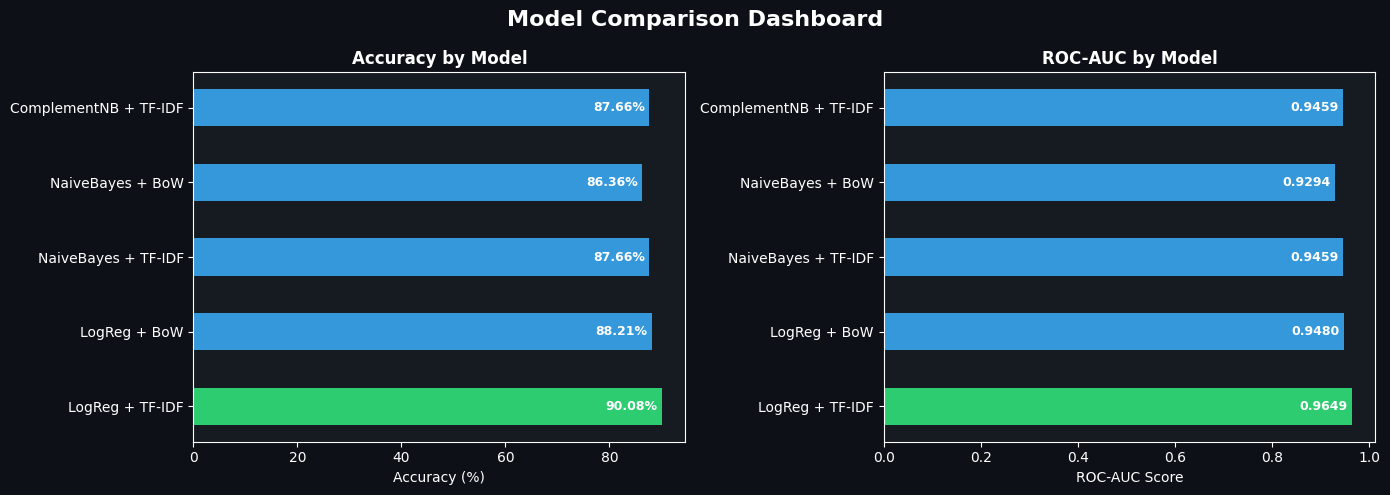

✅ Saved → outputs/01_model_comparison.png


In [45]:
# ── Plot 1: Model Comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG_COLOR)
fig.suptitle("Model Comparison Dashboard", color="white", fontsize=16, fontweight="bold")

model_names = list(results.keys())
accuracies  = [results[m]["accuracy"] * 100 for m in model_names]
aucs        = [results[m]["auc"] for m in model_names]
colors      = [PALETTE_POS if m == best_name else PALETTE_ACC for m in model_names]

for ax, values, xlabel, title in [
    (axes[0], accuracies, "Accuracy (%)",  "Accuracy by Model"),
    (axes[1], aucs,       "ROC-AUC Score", "ROC-AUC by Model"),
]:
    ax.set_facecolor(CARD_COLOR)
    bars = ax.barh(model_names, values, color=colors, edgecolor="none", height=0.5)
    ax.set_xlabel(xlabel, color="white")
    ax.set_title(title, color="white", fontweight="bold")
    ax.tick_params(colors="white")
    for bar, val in zip(bars, values):
        label = f"{val:.2f}%" if xlabel == "Accuracy (%)" else f"{val:.4f}"
        ax.text(val * 0.99, bar.get_y() + bar.get_height()/2,
                label, va="center", ha="right", color="white", fontsize=9, fontweight="bold")

plt.tight_layout()
save_fig("01_model_comparison.png")

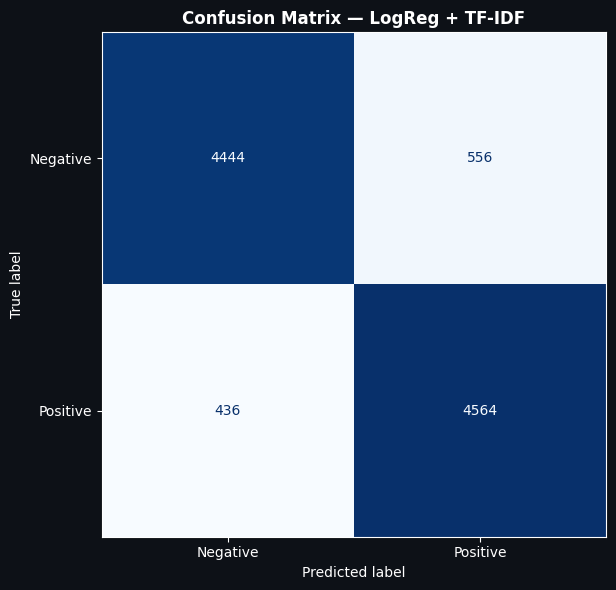

✅ Saved → outputs/02_confusion_matrix.png


In [46]:
# ── Plot 2: Confusion Matrix ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)
cm   = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_name}", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
plt.tight_layout()
save_fig("02_confusion_matrix.png")

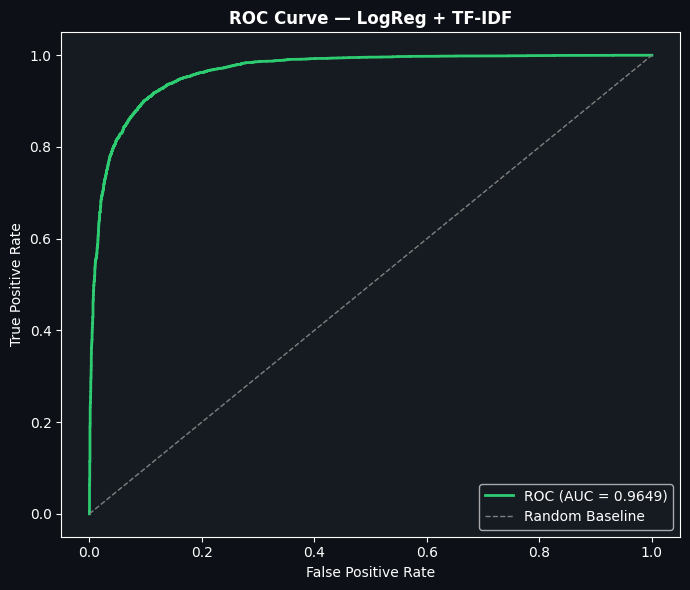

✅ Saved → outputs/03_roc_curve.png


In [47]:
# ── Plot 3: ROC Curve ─────────────────────────────────────────────────────────
if best_probs is not None:
    fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG_COLOR)
    ax.set_facecolor(CARD_COLOR)
    fpr, tpr, _ = roc_curve(y_test, best_probs)
    ax.plot(fpr, tpr, color=PALETTE_POS, lw=2, label=f"ROC (AUC = {results[best_name]['auc']:.4f})")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random Baseline")
    ax.set_xlabel("False Positive Rate", color="white")
    ax.set_ylabel("True Positive Rate", color="white")
    ax.set_title(f"ROC Curve — {best_name}", color="white", fontweight="bold")
    ax.tick_params(colors="white")
    ax.legend(loc="lower right", facecolor=CARD_COLOR, labelcolor="white")
    plt.tight_layout()
    save_fig("03_roc_curve.png")

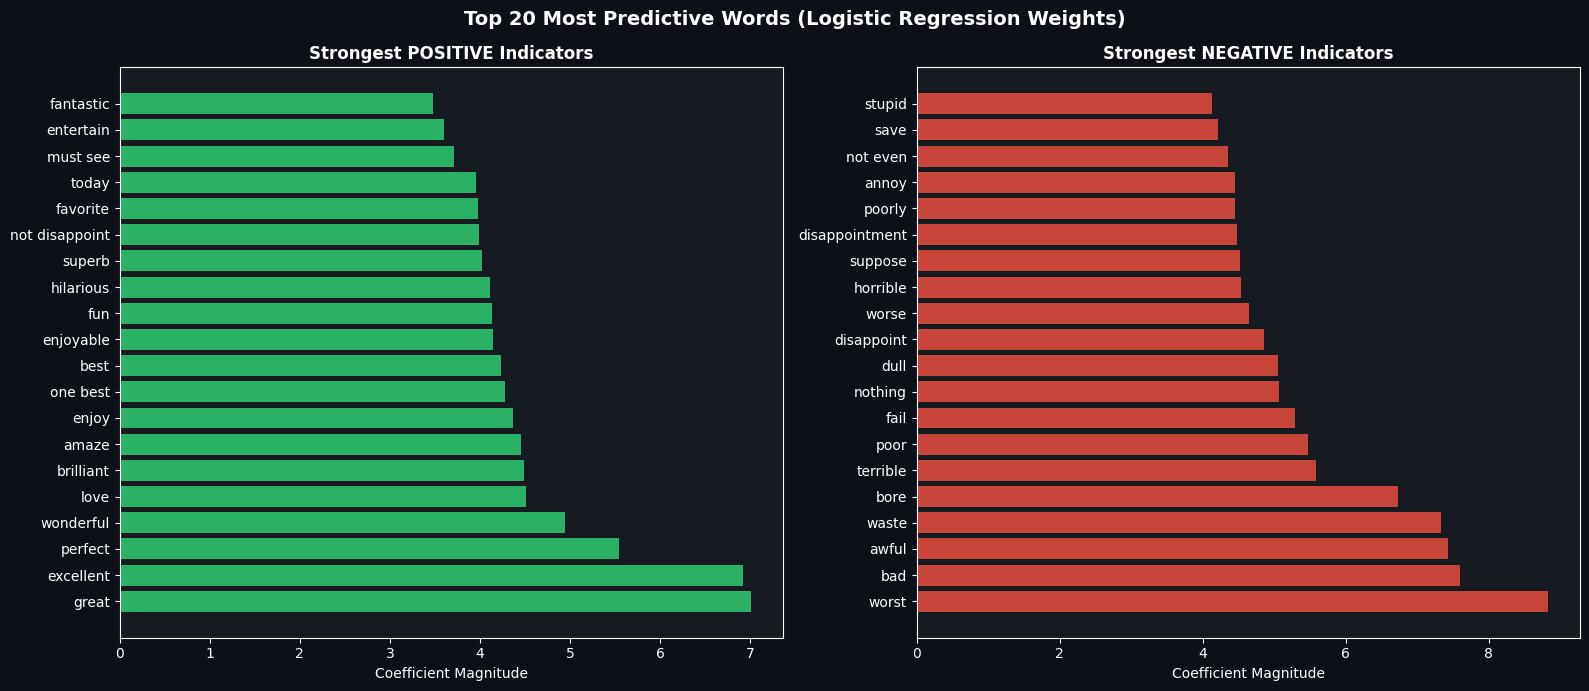

✅ Saved → outputs/04_top_words.png


In [48]:
# ── Plot 4: Top Predictive Words (Logistic Regression Weights) ────────────────
def get_top_features(model, vectorizer, n=20):
    feature_names = vectorizer.get_feature_names_out()
    coef = model.coef_[0]
    top_pos = [(feature_names[i], coef[i]) for i in coef.argsort()[-n:][::-1]]
    top_neg = [(feature_names[i], coef[i]) for i in coef.argsort()[:n]]
    return top_pos, top_neg

lr_model = models["LogReg + TF-IDF"][0]
pos_words, neg_words = get_top_features(lr_model, tfidf_vectorizer, n=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG_COLOR)
fig.suptitle("Top 20 Most Predictive Words (Logistic Regression Weights)",
             color="white", fontsize=14, fontweight="bold")

for ax, word_scores, color, title in [
    (axes[0], pos_words, PALETTE_POS, "Strongest POSITIVE Indicators"),
    (axes[1], neg_words, PALETTE_NEG, "Strongest NEGATIVE Indicators"),
]:
    ax.set_facecolor(CARD_COLOR)
    words  = [w for w, _ in word_scores]
    scores = [abs(s) for _, s in word_scores]
    ax.barh(range(len(words)), scores, align="center", color=color, alpha=0.85, edgecolor="none")
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, color="white")
    ax.set_xlabel("Coefficient Magnitude", color="white")
    ax.set_title(title, color="white", fontweight="bold")
    ax.tick_params(colors="white")

plt.tight_layout()
save_fig("04_top_words.png")

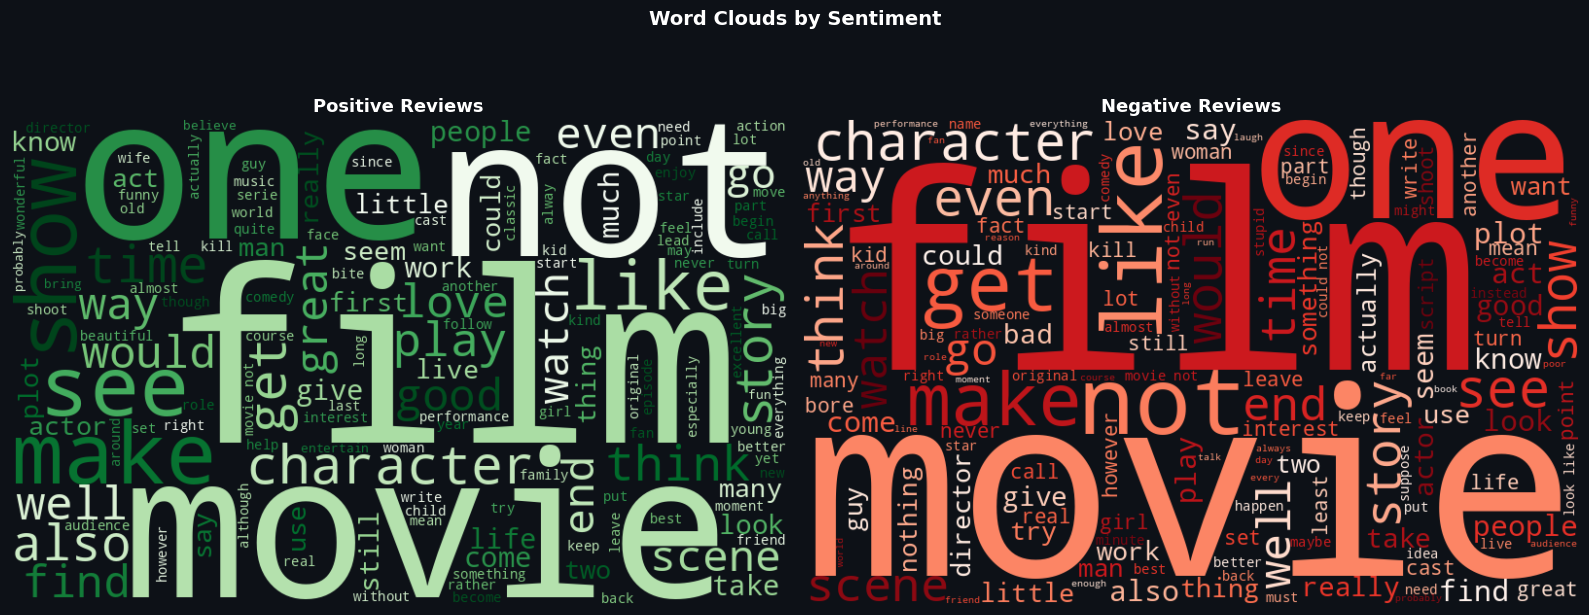

✅ Saved → outputs/05_wordclouds.png


In [49]:
# ── Plot 5: Word Clouds ───────────────────────────────────────────────────────
if WORDCLOUD_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG_COLOR)
    fig.suptitle("Word Clouds by Sentiment", color="white", fontsize=14, fontweight="bold")
    for ax, sentiment, colormap, title in [
        (axes[0], "positive", "Greens", "Positive Reviews"),
        (axes[1], "negative", "Reds",   "Negative Reviews"),
    ]:
        text = " ".join(df[df["sentiment"] == sentiment]["processed_text"].sample(5000, random_state=42))
        wc = WordCloud(width=800, height=500, background_color="#0d1117",
                       colormap=colormap, max_words=150, stopwords=STOP_WORDS).generate(text)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(title, color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_fig("05_wordclouds.png")
else:
    print("⚠ Run: pip install wordcloud  to enable this plot")

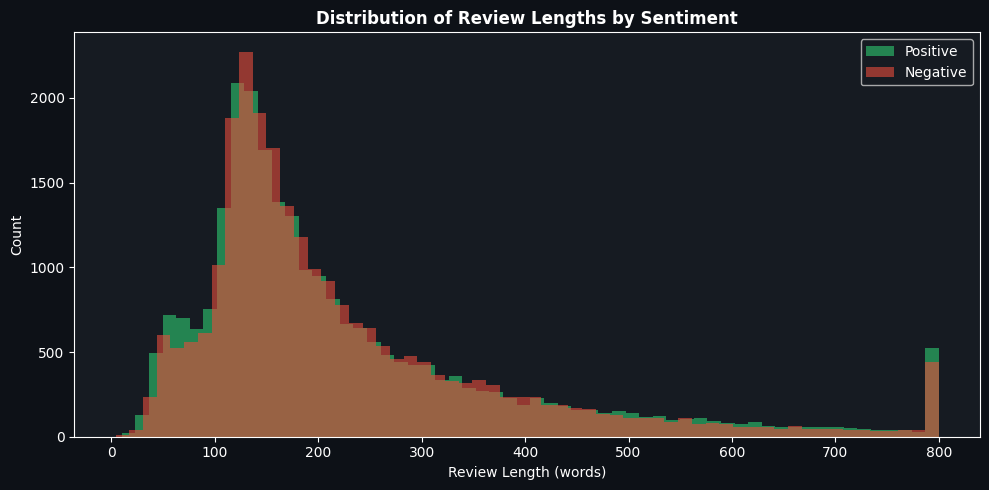

✅ Saved → outputs/06_length_distribution.png


In [50]:
# ── Plot 6: Review Length Distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)
for sentiment, color, label in [("positive", PALETTE_POS, "Positive"), ("negative", PALETTE_NEG, "Negative")]:
    lengths = df[df["sentiment"] == sentiment]["review_length"]
    ax.hist(lengths.clip(upper=800), bins=60, alpha=0.6, color=color, label=label, edgecolor="none")
ax.set_xlabel("Review Length (words)", color="white")
ax.set_ylabel("Count", color="white")
ax.set_title("Distribution of Review Lengths by Sentiment", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.legend(facecolor=CARD_COLOR, labelcolor="white")
plt.tight_layout()
save_fig("06_length_distribution.png")

---
## 🚀 Stage 8: Production Pipeline & Live Inference

Bundle everything into a single `Pipeline` object — ready for deployment.

In [51]:
production_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE,
                               min_df=2, max_df=0.95, sublinear_tf=True)),
    ("model", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)),
])

split_idx = int(len(df) * 0.8)
X_prod    = [preprocess_text(t) for t in df["text"].iloc[:split_idx]]
y_prod    = df["label"].iloc[:split_idx].values
production_pipeline.fit(X_prod, y_prod)
print("✅ Production pipeline trained and ready!")

def predict_sentiment(text: str) -> dict:
    """Full inference: raw text → sentiment + confidence scores."""
    processed = preprocess_text(text)
    proba     = production_pipeline.predict_proba([processed])[0]
    label     = "positive" if proba.argmax() == 1 else "negative"
    return {
        "sentiment"     : label,
        "confidence"    : f"{proba.max()*100:.1f}%",
        "positive_prob" : f"{proba[1]*100:.1f}%",
        "negative_prob" : f"{proba[0]*100:.1f}%",
    }

✅ Production pipeline trained and ready!


In [52]:
# ── Demo predictions ──────────────────────────────────────────────────────────
demo_reviews = [
    "This is one of the greatest films I have ever seen. A masterpiece.",
    "Absolutely terrible. The acting was wooden, the plot made no sense.",
    "Not bad, but not great either. Some nice moments but mostly forgettable.",
    "I don't think this film is good. The director clearly didn't care.",
    "A hidden gem! Beautifully shot with outstanding performances throughout.",
]

print("🔍 LIVE INFERENCE DEMO:\n")
for review in demo_reviews:
    r = predict_sentiment(review)
    icon = "✅" if r["sentiment"] == "positive" else "❌"
    print(f"{icon} {review[:80]}")
    print(f"   → {r['sentiment'].upper()} ({r['confidence']} confidence)  |  pos: {r['positive_prob']}  neg: {r['negative_prob']}")
    print()

🔍 LIVE INFERENCE DEMO:

✅ This is one of the greatest films I have ever seen. A masterpiece.
   → POSITIVE (96.2% confidence)  |  pos: 96.2%  neg: 3.8%

❌ Absolutely terrible. The acting was wooden, the plot made no sense.
   → NEGATIVE (96.5% confidence)  |  pos: 3.5%  neg: 96.5%

❌ Not bad, but not great either. Some nice moments but mostly forgettable.
   → NEGATIVE (72.6% confidence)  |  pos: 27.4%  neg: 72.6%

❌ I don't think this film is good. The director clearly didn't care.
   → NEGATIVE (63.2% confidence)  |  pos: 36.8%  neg: 63.2%

✅ A hidden gem! Beautifully shot with outstanding performances throughout.
   → POSITIVE (98.5% confidence)  |  pos: 98.5%  neg: 1.5%



In [53]:
# ── 🎯 Try your own movie review! ────────────────────────────────────────────
my_review = "This movie is really bad, but I still like it. The actors did a terrible job."

r = predict_sentiment(my_review)
icon = "✅" if r["sentiment"] == "positive" else "❌"
print(f"{icon} Sentiment : {r['sentiment'].upper()} ({r['confidence']} confidence)")
print(f"   Positive  : {r['positive_prob']}")
print(f"   Negative  : {r['negative_prob']}")

❌ Sentiment : NEGATIVE (95.5% confidence)
   Positive  : 4.5%
   Negative  : 95.5%


---
## 🏁 Final Results Summary

In [54]:
print("═" * 65)
print("  📊 FINAL RESULTS SUMMARY")
print("═" * 65)
print(f"  {'Model':<30} {'Accuracy':>10} {'ROC-AUC':>10}")
print("  " + "─" * 55)
for name in sorted(results, key=lambda k: results[k]["accuracy"], reverse=True):
    marker = " ← BEST" if name == best_name else ""
    print(f"  {name:<30} {results[name]['accuracy']*100:>9.2f}% {results[name]['auc']:>10.4f}{marker}")
print()
print("  NEXT STEPS TO IMPROVE:")
print("  1. Hyperparameter tuning with GridSearchCV")
print("  2. Try deep learning: LSTM or BERT (transformers library)")
print("  3. Use unsupervised reviews (train/) for semi-supervised learning")
print("  4. Cross-validation for more reliable evaluation")
print("  5. Deploy as REST API using FastAPI + joblib (model saving)")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  📊 FINAL RESULTS SUMMARY
═════════════════════════════════════════════════════════════════
  Model                            Accuracy    ROC-AUC
  ───────────────────────────────────────────────────────
  LogReg + TF-IDF                    90.08%     0.9649 ← BEST
  LogReg + BoW                       88.21%     0.9480
  NaiveBayes + TF-IDF                87.66%     0.9459
  ComplementNB + TF-IDF              87.66%     0.9459
  NaiveBayes + BoW                   86.36%     0.9294

  NEXT STEPS TO IMPROVE:
  1. Hyperparameter tuning with GridSearchCV
  2. Try deep learning: LSTM or BERT (transformers library)
  3. Use unsupervised reviews (train/) for semi-supervised learning
  4. Cross-validation for more reliable evaluation
  5. Deploy as REST API using FastAPI + joblib (model saving)
═════════════════════════════════════════════════════════════════


In [55]:
import joblib
joblib.dump(production_pipeline, 'sentiment_model.pkl')


['sentiment_model.pkl']